# Reward comparison: old P_diff vs. squareplus

Pulls runs from W&B and plots.
  
Measures:
1. Old P_diff reward vs. squareplus at 0x and 1x noise,
2. Effects of scaling P_diff inside squareplus (1x noise), with a ceiling on the share of steps at P_diff ≤ 0 (x100 run),
3. Accuracy of the implied P_diff, checked against logged P_diff (25x noise, P_diff x10 and 1x noise, P_diff x100).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, wandb
from pathlib import Path

ENTITY, PROJECT = "models-imperial-college-london8968", "plasmax"
OLD_RUNS = {0: "yzeh8hs6", 1: "h4w85xzn"}  # old P_diff reward, 5.12M steps (from dc_noise_multiplier_results)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

api = wandb.Api()

def find(d, k):
    if isinstance(d, dict):
        for kk, v in d.items():
            if kk == k:
                return v
            x = find(v, k)
            if x is not None:
                return x

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/davidcoope/.netrc.


## 1. Compare P_diff reward vs. squareplus (0x and 1x noise)
- The new reward is `squareplus(P_diff) = (x + sqrt(x^2 + 4)) / 2` per surviving step (x = P_diff in GW). 
- New reward is 1 for a surviving step with P_diff = 0.
- To estimate P_diff for runs using the new reward, we can invert squareplus - this is exact if P_diff were constant; squareplus is convex, so it slightly overestimates the true mean.
- Terminal steps have a reward of `log(squareplus(x))` ≈ 0 rather than ≈ 1 (small effect over ~4400 steps)

In [2]:
SQ_PROJECT = "plasmax-squareplus"
SQ_RUNS = {0: "eie5yotw", 1: "3ari4pty"}  # squareplus reward, 10.24M steps
SEEDS = range(3)
RL = ["evaluation/return_mean", "evaluation/episode_length_mean"]

def history(project, rid, nm, keys):
    r = api.run(f"{ENTITY}/{project}/{rid}")
    assert find(r.config, "noise_multiplier") == nm, (nm, rid)
    return r.history(samples=10000, keys=keys, pandas=True).set_index("_step")

def per_seed(nm):
    h = history(SQ_PROJECT, SQ_RUNS[nm], nm, [f"seeds/{s}/{k}" for s in SEEDS for k in RL])
    d = pd.concat({s: pd.DataFrame({"return": h[f"seeds/{s}/{RL[0]}"], "length": h[f"seeds/{s}/{RL[1]}"]})
                   for s in SEEDS}, names=["seed"])
    d["excess"] = d["return"] - d["length"]
    rbar = d["return"] / d["length"]
    d["P_diff_GW"] = rbar - 1 / rbar  # exact squareplus inverse, assuming constant P_diff
    return d

sq = {nm: per_seed(nm) for nm in SQ_RUNS}
# Old runs only logged seed-averaged metrics; old reward was raw P_diff in GW per step.
old = {nm: history(PROJECT, OLD_RUNS[nm], nm, RL) for nm in SQ_RUNS}
old_pdiff = {nm: h[RL[0]] / h[RL[1]] for nm, h in old.items()}

# pd.concat({f"{nm:g}x": d[["length", "excess", "P_diff_GW"]].unstack("seed") for nm, d in sq.items()}, axis=1).round(3)

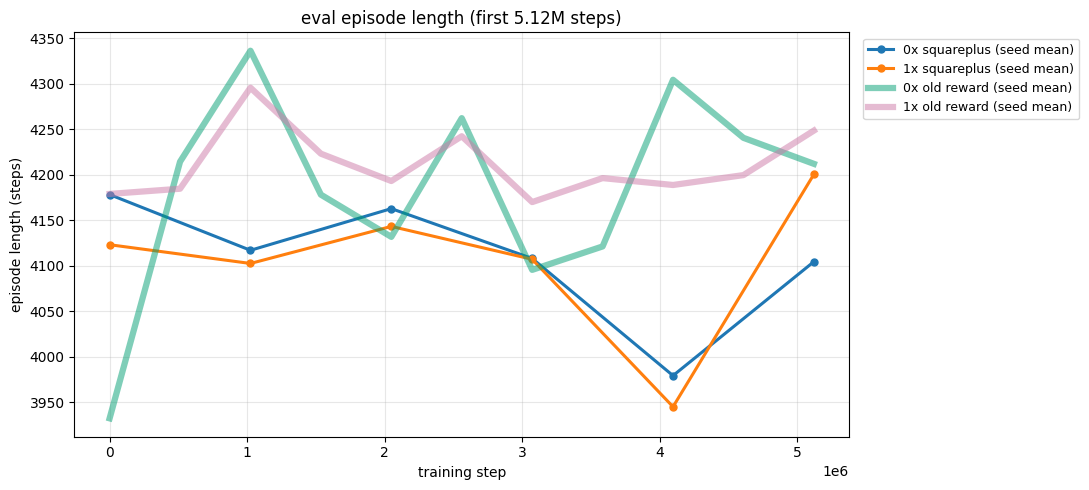

In [3]:
OLD_COLORS = ["#009E73", "#CC79A7"]
T_CROP = 5_120_000  # length plots cropped to the old/scaled runs' length

def seed_lines(ax, col):
    for i, nm in enumerate(SQ_RUNS):
        for s in SEEDS:
            d = sq[nm].xs(s, level="seed")
            ax.plot(d.index, d[col], color=f"C{i}", ls=["-", "--", ":"][s], lw=2.2, marker="o", ms=5,
                    label=f"{nm:g}x squareplus, seed {s}")

def old_lines(ax, series):
    for i, nm in enumerate(SQ_RUNS):
        ax.plot(series[nm].index, series[nm], color=OLD_COLORS[i], lw=4.5, alpha=0.5,
                label=f"{nm:g}x old reward (seed mean)")

def finish(ax, title, ylabel, fname, zero_line=False):
    if zero_line:
        ax.axhline(0, color="k", lw=1)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.set_xlabel("training step"); ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1))
    ax.figure.tight_layout(); save(ax.figure, fname); plt.show()

def sq_length(nm):
    m = sq[nm]["length"].groupby(level="_step").mean()
    return m[m.index <= T_CROP]

fig, ax = plt.subplots(figsize=(11, 5))
for i, nm in enumerate(SQ_RUNS):
    m = sq_length(nm)
    ax.plot(m.index, m, color=f"C{i}", lw=2.2, marker="o", ms=5, label=f"{nm:g}x squareplus (seed mean)")
old_lines(ax, {nm: h[RL[1]] for nm, h in old.items()})
finish(ax, "eval episode length (first 5.12M steps)", "episode length (steps)", "squareplus_episode_length")

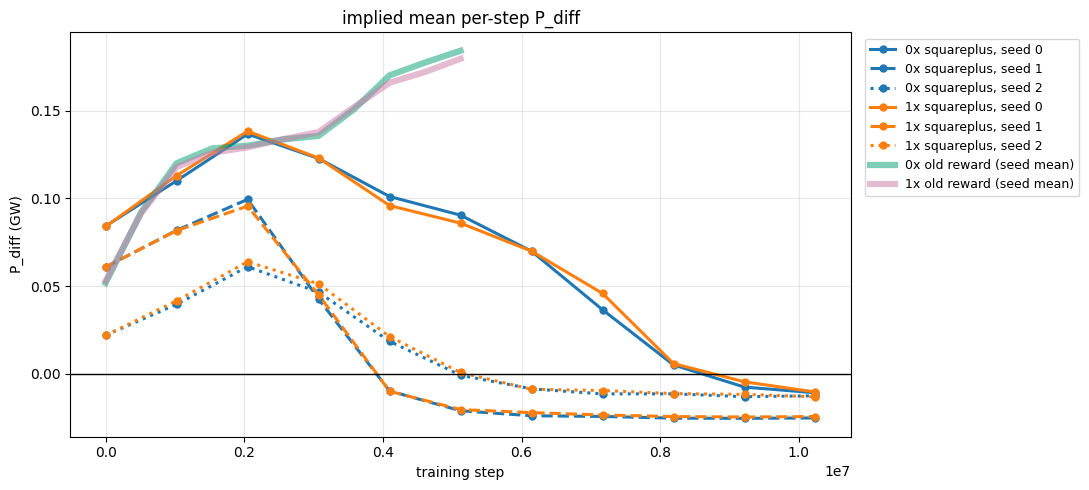

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
seed_lines(ax, "P_diff_GW")
old_lines(ax, old_pdiff)
finish(ax, "implied mean per-step P_diff", "P_diff (GW)", "squareplus_implied_pdiff", zero_line=True)

## 2. Compare effects of scaling P_diff score inside squareplus (1x noise only)
- Scale the P_diff inside the reward using `--env.reward-score-scale s` which pays `squareplus(s * P_diff)`.
- The implied mean P_diff is `(r - 1/r) / s` with `r = return / length`.
- This is an estimate, not the logged P_diff: exact only if P_diff were constant within the eval rollouts (negligible howerver since convexity bias estimated < ~0.002 GW here). 
- The old-reward line is exact up to terminal steps (old reward was raw P_diff; the disrupting step paid the 0 disruption penalty instead).
- The x100 run also logged P_diff exactly (section 3); the implied value is plotted here for consistency with the other lines.
- Lines are seed means.
- All runs use 1024 parallel envs except the one labelled 128 envs.

In [5]:
SCALED_RUNS = {5: "lhnv1b8z", 10: "a7eee7ht", 100: "wfxdgvfq"}  # squareplus(scale * P_diff), 1x noise, 5.12M steps
SCALED_COLORS = {5: "C3", 10: "C4", 100: "C0"}
colors = {1: "C1"} | SCALED_COLORS

def pdiff_run(rid, scale):
    r = api.run(f"{ENTITY}/{SQ_PROJECT}/{rid}")
    assert (find(r.config, "reward_score_scale") or 1.0) == scale, (scale, rid)
    h = history(SQ_PROJECT, rid, 1, [f"seeds/{s}/{k}" for s in SEEDS for k in RL])
    h = h[h.index <= T_CROP]
    rbar = pd.concat({s: h[f"seeds/{s}/{RL[0]}"] / h[f"seeds/{s}/{RL[1]}"] for s in SEEDS}, axis=1)
    return ((rbar - 1 / rbar) / scale).mean(axis=1)  # per-seed inverse, then seed mean

pdiff = {1: pdiff_run(SQ_RUNS[1], 1.0)} | {s: pdiff_run(rid, float(s)) for s, rid in SCALED_RUNS.items()}
old_1x_pdiff = old[1][RL[0]] / old[1][RL[1]]
scaled_len = {scale: history(SQ_PROJECT, rid, 1, RL)[RL[1]] for scale, rid in SCALED_RUNS.items()}

MW_RUN, MW_COLOR = "c5rgytkl", "C2"  # P_diff_MW reward (linear P_diff in MW, no squareplus), 1x noise, 5.12M steps
assert find(api.run(f"{ENTITY}/{SQ_PROJECT}/{MW_RUN}").config, "reward") == "P_diff_MW"
h_mw = history(SQ_PROJECT, MW_RUN, 1, [f"seeds/{s}/{k}" for s in SEEDS for k in RL])
mw_len = pd.concat({s: h_mw[f"seeds/{s}/{RL[1]}"] for s in SEEDS}, axis=1).mean(axis=1)
# Exact up to terminal steps, like the old reward: reward is raw P_diff in MW, 0 on the terminal step.
mw_pdiff = pd.concat({s: h_mw[f"seeds/{s}/{RL[0]}"] / h_mw[f"seeds/{s}/{RL[1]}"] for s in SEEDS}, axis=1).mean(axis=1) / 1e3

NR_RUN, NR_COLOR = "mhw434al", "C5"  # same P_diff_MW reward with reward normalisation on, 1x noise, 5.12M steps
r_nr = api.run(f"{ENTITY}/{SQ_PROJECT}/{NR_RUN}")
assert find(r_nr.config, "reward") == "P_diff_MW" and "normrew" in r_nr.tags
h_nr = history(SQ_PROJECT, NR_RUN, 1, [f"seeds/{s}/{k}" for s in SEEDS for k in RL])  # eval metrics are raw (unnormalised) rewards
nr_len = pd.concat({s: h_nr[f"seeds/{s}/{RL[1]}"] for s in SEEDS}, axis=1).mean(axis=1)
nr_total = pd.concat({s: h_nr[f"seeds/{s}/{RL[0]}"] for s in SEEDS}, axis=1).mean(axis=1) / 1e3

NR128_RUN, NR128_COLOR = "zkio98cp", "C9"  # as NR_RUN but 128 parallel envs instead of 1024
r_nr128 = api.run(f"{ENTITY}/{SQ_PROJECT}/{NR128_RUN}")
assert find(r_nr128.config, "reward") == "P_diff_MW" and "normrew" in r_nr128.tags and find(r_nr128.config, "num_envs") == 128
h_nr128 = history(SQ_PROJECT, NR128_RUN, 1, [f"seeds/{s}/{k}" for s in SEEDS for k in RL])
nr128_len = pd.concat({s: h_nr128[f"seeds/{s}/{RL[1]}"] for s in SEEDS}, axis=1).mean(axis=1)
nr128_total = pd.concat({s: h_nr128[f"seeds/{s}/{RL[0]}"] for s in SEEDS}, axis=1).mean(axis=1) / 1e3

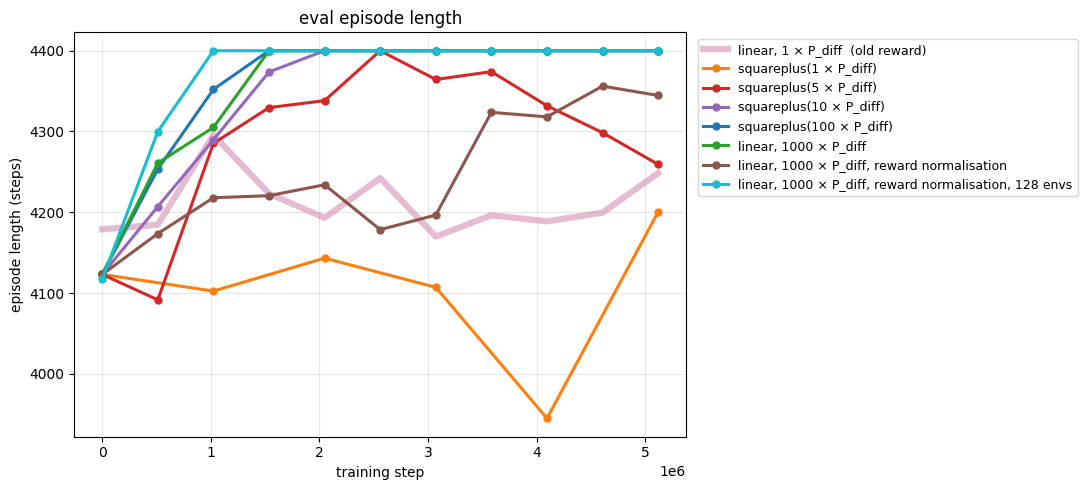

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(old[1].index, old[1][RL[1]], color=OLD_COLORS[1], lw=4.5, alpha=0.5, label="linear, 1 × P_diff  (old reward)")
m = sq_length(1)
ax.plot(m.index, m, color=colors[1], lw=2.2, marker="o", ms=5, label="squareplus(1 × P_diff)")
for scale, h in scaled_len.items():
    ax.plot(h.index, h, color=colors[scale], lw=2.2, marker="o", ms=5, label=f"squareplus({scale} × P_diff)")
ax.plot(mw_len.index, mw_len, color=MW_COLOR, lw=2.2, marker="o", ms=5, label="linear, 1000 × P_diff")
ax.plot(nr_len.index, nr_len, color=NR_COLOR, lw=2.2, marker="o", ms=5, label="linear, 1000 × P_diff, reward normalisation")
ax.plot(nr128_len.index, nr128_len, color=NR128_COLOR, lw=2.2, marker="o", ms=5, label="linear, 1000 × P_diff, reward normalisation, 128 envs")
finish(ax, "eval episode length", "episode length (steps)", "pdiff_scaling_episode_length")

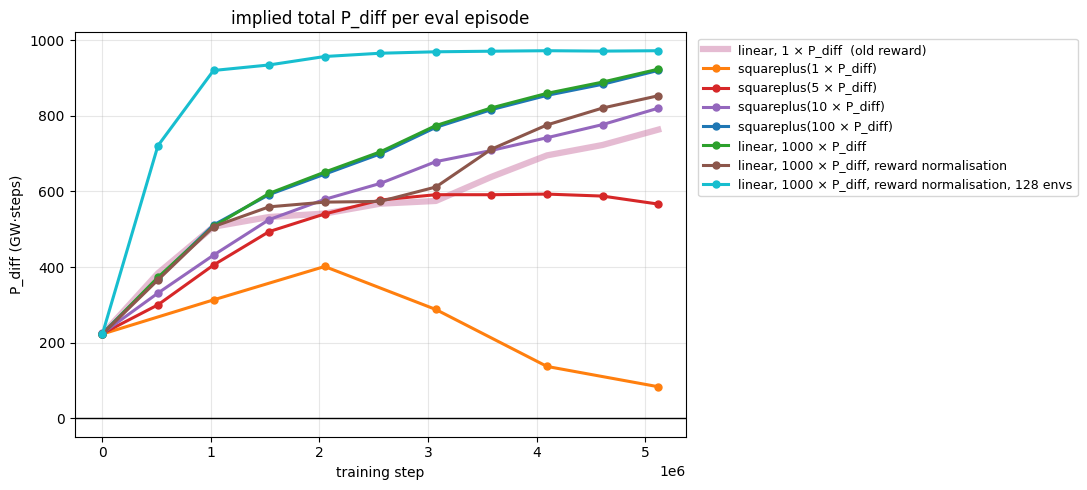

In [7]:
def total_pdiff_run(rid, scale):
    h = history(SQ_PROJECT, rid, 1, [f"seeds/{s}/{k}" for s in SEEDS for k in RL])
    h = h[h.index <= T_CROP]
    ret, length = (pd.concat({s: h[f"seeds/{s}/{k}"] for s in SEEDS}, axis=1) for k in RL)
    rbar = ret / length
    return ((rbar - 1 / rbar) / scale * length).mean(axis=1)  # per-seed implied mean x length, then seed mean

total_pdiff = {1: total_pdiff_run(SQ_RUNS[1], 1.0)} | {s: total_pdiff_run(rid, float(s)) for s, rid in SCALED_RUNS.items()}
# Exact up to terminal steps: these rewards are raw P_diff, so the return is the total.
mw_total = pd.concat({s: h_mw[f"seeds/{s}/{RL[0]}"] for s in SEEDS}, axis=1).mean(axis=1) / 1e3

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(old[1].index, old[1][RL[0]], color=OLD_COLORS[1], lw=4.5, alpha=0.5, label="linear, 1 × P_diff  (old reward)")
for s, m in total_pdiff.items():
    ax.plot(m.index, m, color=colors[s], lw=2.2, marker="o", ms=5, label=f"squareplus({s:g} × P_diff)")
ax.plot(mw_total.index, mw_total, color=MW_COLOR, lw=2.2, marker="o", ms=5, label="linear, 1000 × P_diff")
ax.plot(nr_total.index, nr_total, color=NR_COLOR, lw=2.2, marker="o", ms=5, label="linear, 1000 × P_diff, reward normalisation")
ax.plot(nr128_total.index, nr128_total, color=NR128_COLOR, lw=2.2, marker="o", ms=5, label="linear, 1000 × P_diff, reward normalisation, 128 envs")
finish(ax, "implied total P_diff per eval episode", "P_diff (GW·steps)", "pdiff_scaling_implied_total_pdiff", zero_line=True)

### Ceiling on the share of steps with P_diff ≤ 0 (P_diff x100 run)

- Goal: an upper limit on how much of an eval episode the policy spends at P_diff ≤ 0, using logged values only.
- The bound needs the logged P_diff total (`physics_eval/P_diff_return`), which only the x100 run has, so x1, x5 and x10 are not in the table.
- Inputs per seed and checkpoint, each a mean over the 64 eval episodes (`scale = 100`):
  - `R_bar` = summed reward per episode (`evaluation/return_mean`),
  - `N_bar` = steps per episode (`evaluation/episode_length_mean`),
  - `Z_bar` = summed `scale * P_diff` per episode (`scale * physics_eval/P_diff_return`),
  - `K_bar` = steps per episode with P_diff ≤ 0. Not logged; `max_K_bar` is its ceiling.
- Derivation, with `z = scale * P_diff` and per-step reward `sp = squareplus(z)`:
  - `sp = z + 1/sp`, so summing over an episode gives `sum(1/sp) = R_bar - Z_bar`.
  - A step with `z ≤ 0` has `sp ≤ 1`, so it adds at least 1 to that sum: the `K_bar` such steps add at least `K_bar`.
  - The other `N_bar - K_bar` steps add at least `(N_bar - K_bar)^2 / R_bar` (Cauchy-Schwarz, as their rewards sum to at most `R_bar`).
  - So `R_bar - Z_bar ≥ K_bar + (N_bar - K_bar)^2 / R_bar`, i.e. `K_bar^2 + (R_bar - 2 N_bar) K_bar + (N_bar^2 - R_bar (R_bar - Z_bar)) ≤ 0`.
- `max_K_bar` is the upper root of that quadratic: `max_K_bar = [ (2 N_bar - R_bar) + sqrt( R_bar (5 R_bar - 4 N_bar - 4 Z_bar) ) ] / 2`
- The table shows `100 * max_K_bar / N_bar`, the ceiling as a % of the episode.
- Caveats:
  - It is a ceiling, not a count: ordinary variation in positive P_diff also uses up the budget, so it is loose early in training.
  - It bounds the average over the 64 episodes, not each episode.
  - It is exact only when no episode disrupts (`N_bar = 4400`): a terminal step pays `log(squareplus(z))` in the reward but counts 0 in `P_diff_return`. The earliest checkpoints, where `N_bar < 4400`, are approximate.

In [8]:
NEG_SCALE = 100  # only the x100 run logged P_diff, which Z_bar needs
PD_RETURN = "physics_eval/P_diff_return"  # summed P_diff per eval episode (GW·steps)
h_neg = history(SQ_PROJECT, SCALED_RUNS[NEG_SCALE], 1, [f"seeds/{s}/{k}" for s in SEEDS for k in RL + [PD_RETURN]])
seed_cols = lambda k: pd.concat({s: h_neg[f"seeds/{s}/{k}"] for s in SEEDS}, axis=1)

# One column per seed, one row per checkpoint. A bar means "averaged over the 64 eval episodes".
R_bar = seed_cols(RL[0])                  # summed reward per episode: sum of squareplus(scale * P_diff)
N_bar = seed_cols(RL[1])                  # steps per episode
Z_bar = NEG_SCALE * seed_cols(PD_RETURN)  # summed (scale * P_diff) per episode

# max_K_bar = ceiling on K_bar, the steps per episode with P_diff <= 0. It is the upper root of
#   K_bar^2 + (R_bar - 2 N_bar) K_bar + (N_bar^2 - R_bar (R_bar - Z_bar)) <= 0
# i.e. max_K_bar = [ (2 N_bar - R_bar) + sqrt( R_bar (5 R_bar - 4 N_bar - 4 Z_bar) ) ] / 2
max_K_bar = ((2 * N_bar - R_bar) + np.sqrt(R_bar * (5 * R_bar - 4 * N_bar - 4 * Z_bar))) / 2

pct = (100 * max_K_bar / N_bar).rename(columns=lambda s: f"seed {s}")  # ceiling as % of the episode
pct["seed mean"] = pct.mean(axis=1)
pct.index = [f"{t / 1e6:.2f}M" for t in pct.index]
pct.map("{:.3f}%".format).rename_axis(index="training step", columns="max % of steps with P_diff <= 0")

max % of steps with P_diff <= 0,seed 0,seed 1,seed 2,seed mean
training step,,,,
0.00M,0.856%,1.400%,25.482%,9.246%
0.51M,0.213%,0.341%,3.184%,1.246%
1.02M,0.074%,0.117%,0.497%,0.229%
1.54M,0.032%,0.062%,0.232%,0.109%
2.05M,0.021%,0.045%,0.116%,0.061%
2.56M,0.016%,0.034%,0.071%,0.040%
3.07M,0.012%,0.025%,0.047%,0.028%
3.58M,0.011%,0.019%,0.032%,0.021%
4.10M,0.011%,0.014%,0.026%,0.017%


## 3. Verifying infered mean P_diff accuracy
- Goal of this section is to determine accuracy of squareplus inversion to calculate mean P_diff per step.
  - Sections 1-2 infer P_diff from the reward, since those runs did not log it. Two runs log eval P_diff exactly, so we can check the inversion against them:
    - 25x noise, P_diff x10: logged as the mean per step (`physics_eval/P_diff_GW`).
    - 1x noise, P_diff x100: logged as the total per episode (`physics_eval/P_diff_return`, GW·steps), so the mean per step is `P_diff_return / episode_length`.
- Measured P_diff = mean of `(P_fusion - P_aux_total) * 1e-9` over all valid eval steps, 0 on terminal steps (old-reward convention).
- Implied P_diff = `(r - 1/r) / s` with `r = return / length`, exactly as in section 2.
  - `s` is the scale applied to P_diff within squareplus: 10 and 100 for the two runs.
- Expected differences: squareplus is convex, so the implied value slightly **overestimates** when P_diff varies; terminal steps pay `log(squareplus(s * P_diff))` in the reward but count as 0 in the measured value.
  - Both shrink at x100: `squareplus(x) ≈ x + 1/x` is close to linear at `x = 100 * P_diff`, and that run stops disrupting early in training.

In [9]:
VERIFY_RUN, VERIFY_NM, VERIFY_SCALE = "a51pa0ka", 25, 10.0  # squareplus(10 * P_diff), 25x noise, 5.12M steps
PD = "physics_eval/P_diff_GW"  # mean per step
VERIFY_RUN_100, VERIFY_NM_100, VERIFY_SCALE_100 = "wfxdgvfq", 1, 100.0  # squareplus(100 * P_diff), 1x noise, 5.12M steps
PD_TOTAL = "physics_eval/P_diff_return"  # total per episode (GW·steps)

def verify(rid, nm, scale, pd_key, total=False):
    r = api.run(f"{ENTITY}/{SQ_PROJECT}/{rid}")
    assert find(r.config, "reward_score_scale") == scale, rid
    h = history(SQ_PROJECT, rid, nm, [f"seeds/{s}/{k}" for s in SEEDS for k in RL + [pd_key]])
    col = lambda k: pd.concat({s: h[f"seeds/{s}/{k}"] for s in SEEDS}, axis=1)
    rbar = col(RL[0]) / col(RL[1])
    implied = (rbar - 1 / rbar) / scale
    measured = col(pd_key) / col(RL[1]) if total else col(pd_key)  # total -> mean per step
    return h, implied, measured, implied - measured

h, implied, measured, err = verify(VERIFY_RUN, VERIFY_NM, VERIFY_SCALE, PD)
h_100, implied_100, measured_100, err_100 = verify(VERIFY_RUN_100, VERIFY_NM_100, VERIFY_SCALE_100, PD_TOTAL, total=True)

# print(f"implied - measured over all checkpoints and seeds: mean {err.stack().mean():+.4f} GW, "
#       f"max |.| {err.abs().stack().max():.4f} GW")
# pd.concat({"measured": measured, "implied": implied, "implied - measured": err}, axis=1).round(4)

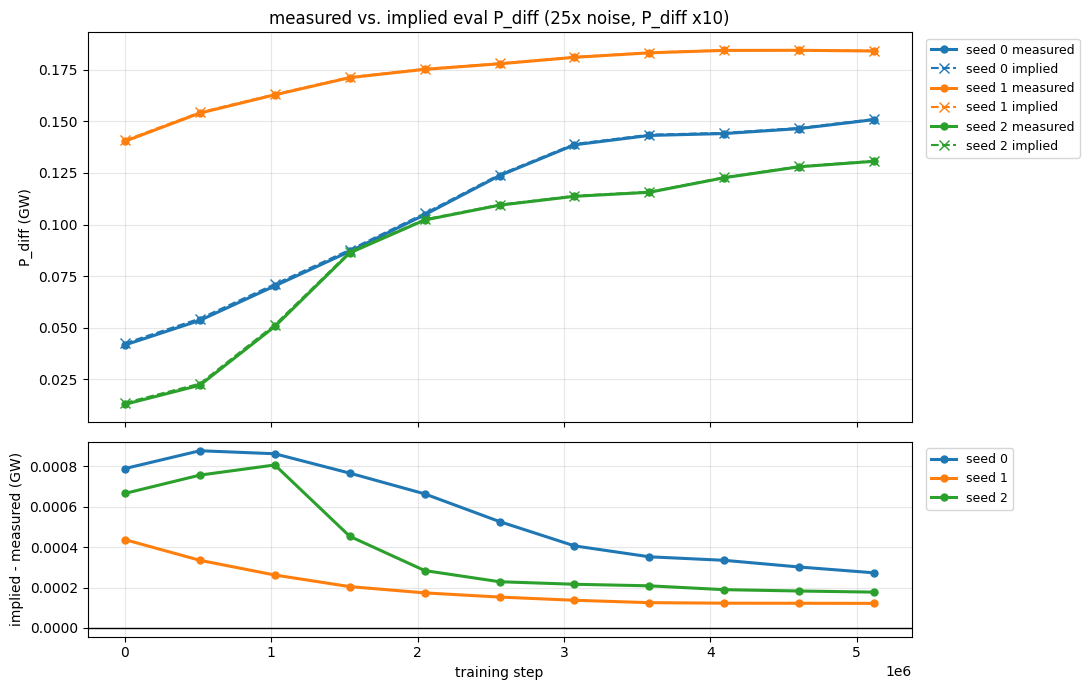

In [10]:
def plot_verify(implied, measured, err, nm, scale, fname):
    fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    for s in SEEDS:
        ax.plot(measured.index, measured[s], color=f"C{s}", lw=2.2, marker="o", ms=5, label=f"seed {s} measured")
        ax.plot(implied.index, implied[s], color=f"C{s}", lw=1.5, ls="--", marker="x", ms=7, label=f"seed {s} implied")
        ax_err.plot(err.index, err[s], color=f"C{s}", lw=2.2, marker="o", ms=5, label=f"seed {s}")
    ax.set_title(f"measured vs. implied eval P_diff ({nm}x noise, P_diff x{scale:g})")
    ax.set_ylabel("P_diff (GW)")
    ax_err.axhline(0, color="k", lw=1)
    ax_err.set_ylabel("implied - measured (GW)"); ax_err.set_xlabel("training step")
    for a in (ax, ax_err):
        a.grid(alpha=0.3); a.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1))
    fig.tight_layout(); save(fig, fname); plt.show()

plot_verify(implied, measured, err, VERIFY_NM, VERIFY_SCALE, "pdiff_verification")

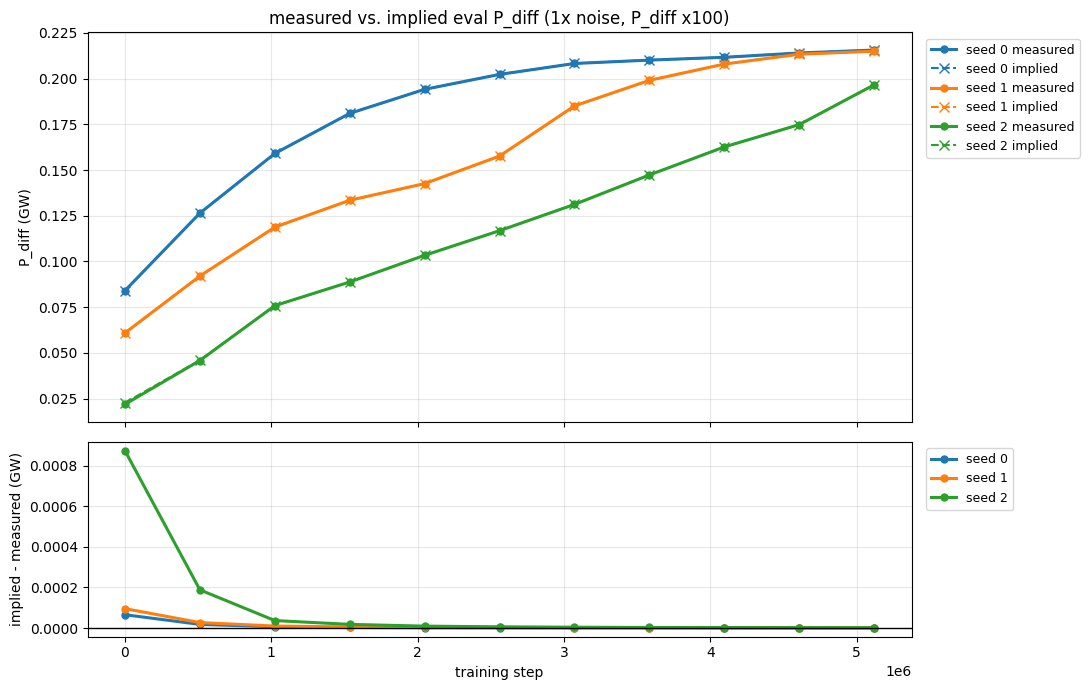

In [11]:
plot_verify(implied_100, measured_100, err_100, VERIFY_NM_100, VERIFY_SCALE_100, "pdiff_verification_x100")

## 4. Compare P_diff between old reward vs 10x scaled squareplus (various noise multipliers)

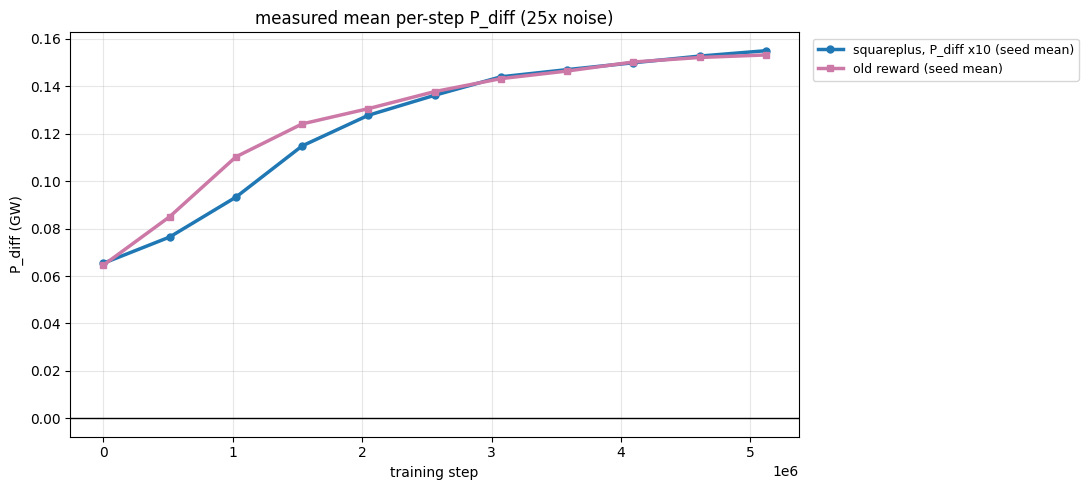

In [12]:
OLD_25X_RUN = "2791b0oj"  # old raw P_diff reward, 25x noise, 5.12M steps (plasmax project)
old_25 = history(PROJECT, OLD_25X_RUN, VERIFY_NM, RL)
old_25_pdiff = old_25[RL[0]] / old_25[RL[1]]  # exact: old reward was raw P_diff, 0 on the terminal step

# Pooled like the old run's return / length: seed-mean P_diff total over seed-mean length.
length = pd.concat({s: h[f"seeds/{s}/{RL[1]}"] for s in SEEDS}, axis=1)
new_25_pdiff = (measured * length).mean(axis=1) / length.mean(axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(new_25_pdiff.index, new_25_pdiff, color="C0", lw=2.5, marker="o", ms=5,
        label=f"squareplus, P_diff x{VERIFY_SCALE:g} (seed mean)")
# Old run logged seed-averaged metrics only (no per-seed history), so just its seed mean.
ax.plot(old_25_pdiff.index, old_25_pdiff, color=OLD_COLORS[1], lw=2.5, marker="s", ms=5,
        label="old reward (seed mean)")
finish(ax, f"measured mean per-step P_diff ({VERIFY_NM}x noise)", "P_diff (GW)", "pdiff_25x_old_vs_scaled", zero_line=True)

# pd.DataFrame({
#     "P_diff (GW)": [old_25_pdiff.iloc[-1], new_25_pdiff.iloc[-1]],
#     "episode length": [old_25[RL[1]].iloc[-1], length.mean(axis=1).iloc[-1]],
# }, index=["old reward", f"squareplus, P_diff x{VERIFY_SCALE:g}"]).round(3)